In [ ]:
# CELL 1: Import libraries and project info

"""
CSC423 NLP TERM PROJECT - MILESTONE 1
Language Identification System for Swahili and Local Kenyan Languages

Student Name: Maryivy Kibali
Student ID: 110062741
Date: 11th March 2026
Instructor: Jonah Marwa
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from datetime import datetime

# Try importing seaborn, but don't crash if it's not there
try:
    import seaborn as sns
    print("✅ Seaborn imported successfully")
    USE_SEABORN = True
except ImportError:
    print("⚠️ Seaborn not installed - will use basic matplotlib")
    USE_SEABORN = False

# Display settings
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 200)
plt.style.use('default')

print("\n✅ Libraries imported successfully!")
print(f"📂 Current working directory: {os.getcwd()}")
print(f"Student: Maryivy Kibali (ID: 110062741)")
print(f"Date: 11th March 2026")

⚠️ Seaborn not installed - will use basic matplotlib

✅ Libraries imported successfully!
📂 Current working directory: /drive
Student: Maryivy Kibali (ID: 110062741)
Date: 11th March 2026


In [ ]:
# CELL 2: Create project folder structure

print("📁 CREATING PROJECT FOLDER STRUCTURE")
print("=" * 50)

# Define folders to create
folders = [
    'data/raw',
    'data/processed',
    'reports/milestone1',
    'src/collection',
    'src/preprocessing',
    'src/models',
    'notebooks',
    'demo'
]

# Create each folder
for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ Created/Verified: {folder}")

print("=" * 50)
print("🎯 Project structure is ready!")

📁 CREATING PROJECT FOLDER STRUCTURE
✅ Created/Verified: data/raw
✅ Created/Verified: data/processed
✅ Created/Verified: reports/milestone1
✅ Created/Verified: src/collection
✅ Created/Verified: src/preprocessing
✅ Created/Verified: src/models
✅ Created/Verified: notebooks
✅ Created/Verified: demo
🎯 Project structure is ready!


In [ ]:
# CELL 3: Create Swahili dataset

print("🗣️ CREATING SWAHILI LANGUAGE SAMPLES")
print("=" * 50)

swahili_samples = [
    # Greetings and basic phrases (10)
    {"text": "Habari za asubuhi", "language": "Swahili"},
    {"text": "Habari za mchana", "language": "Swahili"},
    {"text": "Habari za jioni", "language": "Swahili"},
    {"text": "Mambo vipi?", "language": "Swahili"},
    {"text": "Poa poa", "language": "Swahili"},
    {"text": "Jina langu ni Juma", "language": "Swahili"},
    {"text": "Jina lako nani?", "language": "Swahili"},
    {"text": "Ninaitwa Maria", "language": "Swahili"},
    {"text": "Unatoka wapi?", "language": "Swahili"},
    {"text": "Ninatoka Nairobi", "language": "Swahili"},
    
    # Daily activities (10)
    {"text": "Ninakwenda sokoni", "language": "Swahili"},
    {"text": "Anaenda shuleni", "language": "Swahili"},
    {"text": "Tunakwenda kanisani", "language": "Swahili"},
    {"text": "Wanakwenda mjini", "language": "Swahili"},
    {"text": "Ninakula chakula", "language": "Swahili"},
    {"text": "Anapika ugali", "language": "Swahili"},
    {"text": "Tunanywa chai", "language": "Swahili"},
    {"text": "Wanacheza mpira", "language": "Swahili"},
    {"text": "Ninasoma kitabu", "language": "Swahili"},
    {"text": "Anaandika barua", "language": "Swahili"},
    
    # Time and weather (8)
    {"text": "Tutaonana kesho", "language": "Swahili"},
    {"text": "Nitakuja kesho", "language": "Swahili"},
    {"text": "Leo ni Jumatatu", "language": "Swahili"},
    {"text": "Mvua inanyesha", "language": "Swahili"},
    {"text": "Jua linawaka", "language": "Swahili"},
    {"text": "Baridi kali leo", "language": "Swahili"},
    {"text": "Kuna upepo", "language": "Swahili"},
    {"text": "Kesho kutakuwa na jua", "language": "Swahili"},
    
    # Feelings and needs (8)
    {"text": "Nina njaa sana", "language": "Swahili"},
    {"text": "Nina kiu", "language": "Swahili"},
    {"text": "Nina furaha", "language": "Swahili"},
    {"text": "Nina huzuni", "language": "Swahili"},
    {"text": "Nina uchovu", "language": "Swahili"},
    {"text": "Nina homa", "language": "Swahili"},
    {"text": "Nahitaji msaada", "language": "Swahili"},
    {"text": "Nataka kupumzika", "language": "Swahili"},
    
    # Family and people (6)
    {"text": "Mama yuko nyumbani", "language": "Swahili"},
    {"text": "Baba anafanya kazi", "language": "Swahili"},
    {"text": "Dada yangu anasoma", "language": "Swahili"},
    {"text": "Kaka yangu anacheza", "language": "Swahili"},
    {"text": "Watoto wanacheka", "language": "Swahili"},
    {"text": "Rafiki yangu anakuja", "language": "Swahili"},
    
    # Questions (6)
    {"text": "Unafanya nini?", "language": "Swahili"},
    {"text": "Unaenda wapi?", "language": "Swahili"},
    {"text": "Unakula nini?", "language": "Swahili"},
    {"text": "Unasema lugha gani?", "language": "Swahili"},
    {"text": "Una umri gani?", "language": "Swahili"},
    {"text": "Hii ni bei gani?", "language": "Swahili"},
    
    # Additional common phrases (12 more to reach 60)
    {"text": "Karibu nyumbani", "language": "Swahili"},
    {"text": "Asante sana", "language": "Swahili"},
    {"text": "Tafadhali njoo hapa", "language": "Swahili"},
    {"text": "Samahani", "language": "Swahili"},
    {"text": "Ndiyo", "language": "Swahili"},
    {"text": "Hapana", "language": "Swahili"},
    {"text": "Sijui", "language": "Swahili"},
    {"text": "Naelewa", "language": "Swahili"},
    {"text": "Sielewi", "language": "Swahili"},
    {"text": "Pole pole", "language": "Swahili"},
    {"text": "Haraka haraka", "language": "Swahili"},
    {"text": "Kesho asubuhi", "language": "Swahili"},
]

print(f"✅ Created {len(swahili_samples)} Swahili samples")
print("\n📝 FIRST 10 SWAHILI SAMPLES:")
print("-" * 50)
for i in range(10):
    print(f"{i+1:2d}. {swahili_samples[i]['text']}")
print("-" * 50)
print(f"Total Swahili samples ready: {len(swahili_samples)}")

🗣️ CREATING SWAHILI LANGUAGE SAMPLES
✅ Created 60 Swahili samples

📝 FIRST 10 SWAHILI SAMPLES:
--------------------------------------------------
 1. Habari za asubuhi
 2. Habari za mchana
 3. Habari za jioni
 4. Mambo vipi?
 5. Poa poa
 6. Jina langu ni Juma
 7. Jina lako nani?
 8. Ninaitwa Maria
 9. Unatoka wapi?
10. Ninatoka Nairobi
--------------------------------------------------
Total Swahili samples ready: 60


In [ ]:
# CELL 4: Create English dataset

print("🗣️ CREATING ENGLISH LANGUAGE SAMPLES")
print("=" * 50)

english_samples = [
    # Greetings (10)
    {"text": "Good morning, how are you?", "language": "English"},
    {"text": "Good afternoon", "language": "English"},
    {"text": "Good evening", "language": "English"},
    {"text": "Hello, nice to meet you", "language": "English"},
    {"text": "How is your day going?", "language": "English"},
    {"text": "What's up?", "language": "English"},
    {"text": "I'm doing well, thanks", "language": "English"},
    {"text": "My name is John", "language": "English"},
    {"text": "What is your name?", "language": "English"},
    {"text": "Where are you from?", "language": "English"},
    
    # Daily activities (10)
    {"text": "I am going to school", "language": "English"},
    {"text": "She works at the hospital", "language": "English"},
    {"text": "They are playing football", "language": "English"},
    {"text": "We are having dinner", "language": "English"},
    {"text": "I need to buy groceries", "language": "English"},
    {"text": "He is reading a book", "language": "English"},
    {"text": "She is writing a letter", "language": "English"},
    {"text": "We are watching a movie", "language": "English"},
    {"text": "They are cooking food", "language": "English"},
    {"text": "I am taking a shower", "language": "English"},
    
    # Weather (6)
    {"text": "The weather is nice today", "language": "English"},
    {"text": "It is raining outside", "language": "English"},
    {"text": "The sun is shining brightly", "language": "English"},
    {"text": "It's very cold this morning", "language": "English"},
    {"text": "There is a strong wind", "language": "English"},
    {"text": "It might rain tomorrow", "language": "English"},
    
    # Requests and needs (8)
    {"text": "Please pass me the salt", "language": "English"},
    {"text": "Can you help me with this?", "language": "English"},
    {"text": "I need some water", "language": "English"},
    {"text": "Could you tell me the time?", "language": "English"},
    {"text": "I am hungry", "language": "English"},
    {"text": "I am thirsty", "language": "English"},
    {"text": "I am tired", "language": "English"},
    {"text": "I need to rest", "language": "English"},
    
    # Opinions and feelings (8)
    {"text": "I love reading books", "language": "English"},
    {"text": "The food is delicious", "language": "English"},
    {"text": "The movie was interesting", "language": "English"},
    {"text": "She sings beautifully", "language": "English"},
    {"text": "He runs very fast", "language": "English"},
    {"text": "This project is exciting", "language": "English"},
    {"text": "I feel happy today", "language": "English"},
    {"text": "That makes me sad", "language": "English"},
    
    # Future plans (6)
    {"text": "I will call you later", "language": "English"},
    {"text": "See you tomorrow", "language": "English"},
    {"text": "Have a nice day", "language": "English"},
    {"text": "We will meet next week", "language": "English"},
    {"text": "I am going to travel", "language": "English"},
    {"text": "She will start her new job", "language": "English"},
    
    # Questions (6)
    {"text": "What time is the meeting?", "language": "English"},
    {"text": "Where is the nearest bank?", "language": "English"},
    {"text": "How much does this cost?", "language": "English"},
    {"text": "When will you arrive?", "language": "English"},
    {"text": "Why are you late?", "language": "English"},
    {"text": "Who is that person?", "language": "English"},
    
    # Additional common phrases (10)
    {"text": "I love you", "language": "English"},
    {"text": "I miss you", "language": "English"},
    {"text": "Take care", "language": "English"},
    {"text": "Good luck", "language": "English"},
    {"text": "Congratulations", "language": "English"},
    {"text": "Happy birthday", "language": "English"},
    {"text": "Merry Christmas", "language": "English"},
    {"text": "I don't understand", "language": "English"},
    {"text": "Please speak slowly", "language": "English"},
    {"text": "Can you repeat that?", "language": "English"},
]

print(f"✅ Created {len(english_samples)} English samples")
print("\n📝 FIRST 10 ENGLISH SAMPLES:")
print("-" * 50)
for i in range(10):
    print(f"{i+1:2d}. {english_samples[i]['text']}")
print("-" * 50)
print(f"Total English samples ready: {len(english_samples)}")

🗣️ CREATING ENGLISH LANGUAGE SAMPLES
✅ Created 64 English samples

📝 FIRST 10 ENGLISH SAMPLES:
--------------------------------------------------
 1. Good morning, how are you?
 2. Good afternoon
 3. Good evening
 4. Hello, nice to meet you
 5. How is your day going?
 6. What's up?
 7. I'm doing well, thanks
 8. My name is John
 9. What is your name?
10. Where are you from?
--------------------------------------------------
Total English samples ready: 64


In [ ]:
# CELL 5: Create Sheng dataset

print("🗣️ CREATING SHENG LANGUAGE SAMPLES")
print("=" * 50)

sheng_samples = [
    {"text": "Niko poa sana", "language": "Sheng"},
    {"text": "Poa poa", "language": "Sheng"},
    {"text": "Freshi kabisa", "language": "Sheng"},
    {"text": "Mambo vipi?", "language": "Sheng"},
    {"text": "Safi sana", "language": "Sheng"},
    {"text": "Wacha tuende base", "language": "Sheng"},
    {"text": "Naskia job yako iko poa", "language": "Sheng"},
    {"text": "Uko wapi msee?", "language": "Sheng"},
    {"text": "Niko hapa town", "language": "Sheng"},
    {"text": "Twende mboka kesho", "language": "Sheng"},
    {"text": "Hio ni ngumu sana", "language": "Sheng"},
    {"text": "Nimekula chapo na ndengu", "language": "Sheng"},
    {"text": "Wacha story za jaba", "language": "Sheng"},
    {"text": "Msee huyo ni dame", "language": "Sheng"},
    {"text": "Tumesota pia", "language": "Sheng"},
    {"text": "Niko na mabeshte wangu", "language": "Sheng"},
    {"text": "Utaje kangara kesho?", "language": "Sheng"},
    {"text": "Hio ndio mboka safi", "language": "Sheng"},
    {"text": "Ananifanya nidobe", "language": "Sheng"},
    {"text": "Wacha ujanja msee", "language": "Sheng"},
    {"text": "Nimechapa kazi leo", "language": "Sheng"},
    {"text": "Huyo dem ni mrembo", "language": "Sheng"},
    {"text": "Niko na njaa kidogo", "language": "Sheng"},
    {"text": "Twende tukaone vile itakua", "language": "Sheng"},
    {"text": "Umenizoea?", "language": "Sheng"},
    {"text": "Nimekua nashibe", "language": "Sheng"},
    {"text": "Hii ni kitu poa", "language": "Sheng"},
    {"text": "Si poa hio", "language": "Sheng"},
    {"text": "Wacha kucheza msee", "language": "Sheng"},
    {"text": "Nimekurop", "language": "Sheng"},
    {"text": "Let's go shopping kesho", "language": "Sheng"},
    {"text": "That movie ilikua poa", "language": "Sheng"},
    {"text": "My guy amenirop", "language": "Sheng"},
    {"text": "This place ni moto", "language": "Sheng"},
    {"text": "Wacha tupige story", "language": "Sheng"},
    {"text": "Job yangu iko fresh", "language": "Sheng"},
    {"text": "Niko sure kesho nitakuja", "language": "Sheng"},
    {"text": "Mboka imejaa watu", "language": "Sheng"},
    {"text": "Hio gari ni dooo", "language": "Sheng"},
    {"text": "Ananishow tu", "language": "Sheng"},
    {"text": "Umeenda wapi mboka?", "language": "Sheng"},
    {"text": "Niko na noma", "language": "Sheng"},
    {"text": "Tutane tuone", "language": "Sheng"},
    {"text": "Hii ni kitu gani?", "language": "Sheng"},
    {"text": "Unanivibe?", "language": "Sheng"},
    {"text": "Nimekuzoea msee", "language": "Sheng"},
    {"text": "Wacha tuchome", "language": "Sheng"},
    {"text": "Niko down", "language": "Sheng"},
    {"text": "Hiyo ni story ya jaba", "language": "Sheng"},
    {"text": "Twende tunywe juice", "language": "Sheng"},
    {"text": "Narejea tu", "language": "Sheng"},
    {"text": "Utado?", "language": "Sheng"},
    {"text": "Sasa", "language": "Sheng"},
    {"text": "Jamaa yule ni msee", "language": "Sheng"},
    {"text": "Tunaeza piga mboka", "language": "Sheng"},
    {"text": "Niko na budget ndogo", "language": "Sheng"},
    {"text": "Unaniexpose msee", "language": "Sheng"},
    {"text": "Hii ni serious", "language": "Sheng"},
    {"text": "Twende lunch", "language": "Sheng"},
    {"text": "Nimekubali", "language": "Sheng"},
]

print(f"✅ Created {len(sheng_samples)} Sheng samples")
print("\n📝 FIRST 10 SHENG SAMPLES:")
print("-" * 50)
for i in range(10):
    print(f"{i+1:2d}. {sheng_samples[i]['text']}")
print("-" * 50)
print(f"Total Sheng samples ready: {len(sheng_samples)}")

🗣️ CREATING SHENG LANGUAGE SAMPLES
✅ Created 60 Sheng samples

📝 FIRST 10 SHENG SAMPLES:
--------------------------------------------------
 1. Niko poa sana
 2. Poa poa
 3. Freshi kabisa
 4. Mambo vipi?
 5. Safi sana
 6. Wacha tuende base
 7. Naskia job yako iko poa
 8. Uko wapi msee?
 9. Niko hapa town
10. Twende mboka kesho
--------------------------------------------------
Total Sheng samples ready: 60


In [ ]:
# CELL 6: Create Luo dataset

print("🗣️ CREATING LUO LANGUAGE SAMPLES")
print("=" * 50)

luo_samples = [
    {"text": "Ber novinyo", "language": "Luo"},
    {"text": "Ber odhiambo", "language": "Luo"},
    {"text": "Ber ochamo", "language": "Luo"},
    {"text": "Idhi nade?", "language": "Luo"},
    {"text": "Adhi maber", "language": "Luo"},
    {"text": "In ie?", "language": "Luo"},
    {"text": "Ee, anie", "language": "Luo"},
    {"text": "Nyingi ng'a?", "language": "Luo"},
    {"text": "Nyinga John", "language": "Luo"},
    {"text": "I a wanye?", "language": "Luo"},
    {"text": "Adhi dala", "language": "Luo"},
    {"text": "Adhi skul", "language": "Luo"},
    {"text": "Adhi tich", "language": "Luo"},
    {"text": "Adhi chiro", "language": "Luo"},
    {"text": "Nyathi chiemo", "language": "Luo"},
    {"text": "Gweno chiemo", "language": "Luo"},
    {"text": "Ring'o otek", "language": "Luo"},
    {"text": "Pi oloo", "language": "Luo"},
    {"text": "Chai omyo", "language": "Luo"},
    {"text": "An gi tich matek", "language": "Luo"},
    {"text": "Mera ni dala", "language": "Luo"},
    {"text": "Wuora ni tich", "language": "Luo"},
    {"text": "Nyamera ni skul", "language": "Luo"},
    {"text": "Owadha ni gweng'", "language": "Luo"},
    {"text": "Nyithindo gin gi remo", "language": "Luo"},
    {"text": "Jodongo ni dala", "language": "Luo"},
    {"text": "Min nyathi obiro", "language": "Luo"},
    {"text": "Wuon ot odhi", "language": "Luo"},
    {"text": "Koth chue", "language": "Luo"},
    {"text": "Chieng' ler", "language": "Luo"},
    {"text": "Yamo kudho", "language": "Luo"},
    {"text": "Koyo ng'ich", "language": "Luo"},
    {"text": "Okinyi ber", "language": "Luo"},
    {"text": "Odhiambo ber", "language": "Luo"},
    {"text": "Koro ne en ndalo mag koth", "language": "Luo"},
    {"text": "Ndalo ler kawuono", "language": "Luo"},
    {"text": "Idhi kanye?", "language": "Luo"},
    {"text": "I aa kanye?", "language": "Luo"},
    {"text": "Itimo ang'o?", "language": "Luo"},
    {"text": "In ng'a?", "language": "Luo"},
    {"text": "Magi ni ng'o?", "language": "Luo"},
    {"text": "En ng'ama?", "language": "Luo"},
    {"text": "Wang'eyo kanye?", "language": "Luo"},
    {"text": "Koro en sa adi?", "language": "Luo"},
    {"text": "Erokamano", "language": "Luo"},
    {"text": "Mos mos", "language": "Luo"},
    {"text": "Ooyo", "language": "Luo"},
    {"text": "Ee", "language": "Luo"},
    {"text": "Ooyo, ok adhi", "language": "Luo"},
    {"text": "An ka da", "language": "Luo"},
    {"text": "Wuok odiochieng' ber", "language": "Luo"},
    {"text": "Ogwenyo", "language": "Luo"},
    {"text": "Nyasaye ogwedhi", "language": "Luo"},
    {"text": "Yesu ohera", "language": "Luo"},
    {"text": "Lemna ne Nyasaye", "language": "Luo"},
    {"text": "Dhi gi kwe", "language": "Luo"},
    {"text": "Nyasaye konyi", "language": "Luo"},
    {"text": "Ruoth ogwedhi", "language": "Luo"},
    {"text": "An gi chiemo", "language": "Luo"},
    {"text": "Adwa pi", "language": "Luo"},
    {"text": "Nind maber", "language": "Luo"},
    {"text": "Ihero?", "language": "Luo"},
    {"text": "Aheri", "language": "Luo"},
    {"text": "Wan gi kwe", "language": "Luo"},
    {"text": "Bi ka", "language": "Luo"},
    {"text": "Bed maber", "language": "Luo"},
    {"text": "Wang'eyo", "language": "Luo"},
    {"text": "Koro adhi", "language": "Luo"},
]

print(f"✅ Created {len(luo_samples)} Luo samples")
print("\n📝 FIRST 10 LUO SAMPLES:")
print("-" * 50)
for i in range(10):
    print(f"{i+1:2d}. {luo_samples[i]['text']}")
print("-" * 50)
print(f"Total Luo samples ready: {len(luo_samples)}")

🗣️ CREATING LUO LANGUAGE SAMPLES
✅ Created 68 Luo samples

📝 FIRST 10 LUO SAMPLES:
--------------------------------------------------
 1. Ber novinyo
 2. Ber odhiambo
 3. Ber ochamo
 4. Idhi nade?
 5. Adhi maber
 6. In ie?
 7. Ee, anie
 8. Nyingi ng'a?
 9. Nyinga John
10. I a wanye?
--------------------------------------------------
Total Luo samples ready: 68


In [ ]:
# CELL 7: Combine all datasets into one

print("🔄 COMBINING ALL LANGUAGE DATASETS")
print("=" * 50)

# Combine all samples
all_samples = swahili_samples + english_samples + sheng_samples + luo_samples

print(f"📊 TOTAL SAMPLES COLLECTED: {len(all_samples)}")
print("-" * 30)
print(f"   Swahili: {len(swahili_samples)} samples")
print(f"   English: {len(english_samples)} samples") 
print(f"   Sheng: {len(sheng_samples)} samples")
print(f"   Luo: {len(luo_samples)} samples")
print("-" * 30)
print(f"   TOTAL: {len(all_samples)} samples")

# Create DataFrame
df = pd.DataFrame(all_samples)

# Shuffle the dataset (mix up the order so languages are randomized)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n✅ Combined dataset created and shuffled!")
print(f"📋 DataFrame shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"📋 Columns: {list(df.columns)}")

# Quick check
print("\n🔍 First 5 rows after shuffling:")
print(df.head(5).to_string(index=False))

🔄 COMBINING ALL LANGUAGE DATASETS
📊 TOTAL SAMPLES COLLECTED: 252
------------------------------
   Swahili: 60 samples
   English: 64 samples
   Sheng: 60 samples
   Luo: 68 samples
------------------------------
   TOTAL: 252 samples

✅ Combined dataset created and shuffled!
📋 DataFrame shape: 252 rows × 2 columns
📋 Columns: ['text', 'language']

🔍 First 5 rows after shuffling:
                 text language
         Niko na noma    Sheng
      Jina lako nani?  Swahili
When will you arrive?  English
Hiyo ni story ya jaba    Sheng
           I miss you  English


In [ ]:
# CELL 8: Preview your complete dataset

print("📝 PREVIEWING COMPLETE DATASET")
print("=" * 70)

# Show first 20 samples
print("\n📋 FIRST 20 SAMPLES:")
print("-" * 70)
for i in range(20):
    print(f"{i+1:2d}. [{df.loc[i, 'language']:8}] {df.loc[i, 'text']}")
print("-" * 70)

# Show random 10 samples
print("\n📋 10 RANDOM SAMPLES:")
print("-" * 70)
random_indices = random.sample(range(len(df)), 10)
for i, idx in enumerate(sorted(random_indices)):
    print(f"{i+1:2d}. [{df.loc[idx, 'language']:8}] {df.loc[idx, 'text']}")
print("-" * 70)

print(f"\n✅ Total samples in dataset: {len(df)}")

📝 PREVIEWING COMPLETE DATASET

📋 FIRST 20 SAMPLES:
----------------------------------------------------------------------
 1. [Sheng   ] Niko na noma
 2. [Swahili ] Jina lako nani?
 3. [English ] When will you arrive?
 4. [Sheng   ] Hiyo ni story ya jaba
 5. [English ] I miss you
 6. [Sheng   ] Nimekubali
 7. [Luo     ] Gweno chiemo
 8. [Luo     ] Ogwenyo
 9. [Swahili ] Ninatoka Nairobi
10. [Swahili ] Nina furaha
11. [English ] Good morning, how are you?
12. [Luo     ] Koro ne en ndalo mag koth
13. [Luo     ] Wang'eyo kanye?
14. [Sheng   ] Job yangu iko fresh
15. [English ] What is your name?
16. [Sheng   ] Umenizoea?
17. [Luo     ] Adhi tich
18. [Swahili ] Anapika ugali
19. [English ] That makes me sad
20. [Swahili ] Jua linawaka
----------------------------------------------------------------------

📋 10 RANDOM SAMPLES:
----------------------------------------------------------------------
 1. [Luo     ] Ogwenyo
 2. [English ] I'm doing well, thanks
 3. [Sheng   ] Sasa
 4. [Luo     ]

📊 LANGUAGE DISTRIBUTION ANALYSIS

📈 COUNTS PER LANGUAGE:
------------------------------
Luo      :  68 samples (27.0%)
English  :  64 samples (25.4%)
Sheng    :  60 samples (23.8%)
Swahili  :  60 samples (23.8%)


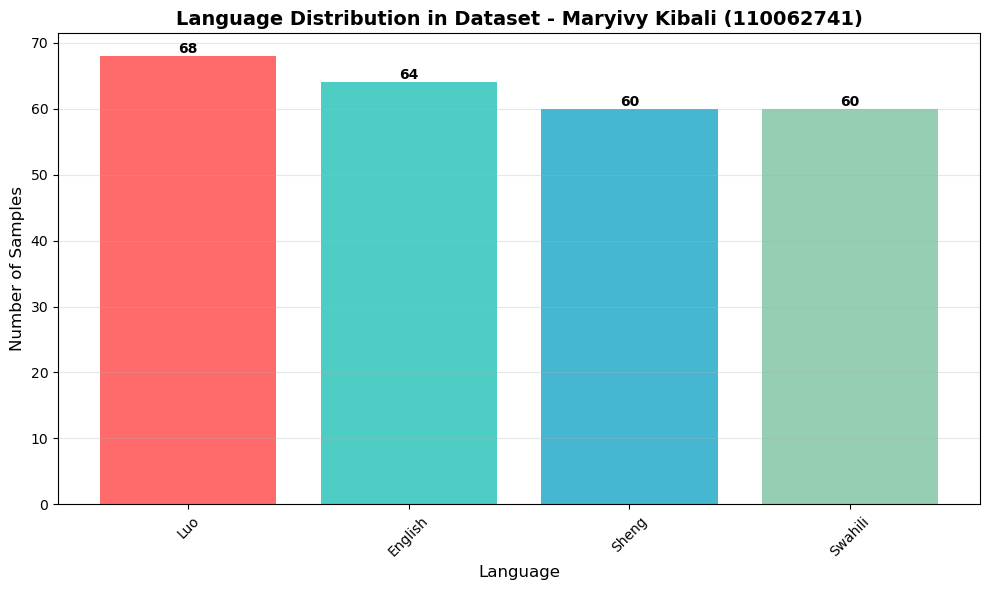


✅ Distribution analysis complete!
📊 Plot saved as 'language_distribution.png'


In [ ]:
# CELL 9: Check language distribution in the dataset

print("📊 LANGUAGE DISTRIBUTION ANALYSIS")
print("=" * 50)

# Count samples per language
lang_counts = df['language'].value_counts()
total_samples = len(df)

print("\n📈 COUNTS PER LANGUAGE:")
print("-" * 30)
for lang, count in lang_counts.items():
    percentage = (count/total_samples)*100
    print(f"{lang:8} : {count:3} samples ({percentage:.1f}%)")

# Create bar chart
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = plt.bar(lang_counts.index, lang_counts.values, color=colors)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.title('Language Distribution in Dataset - Maryivy Kibali (110062741)', fontsize=14, fontweight='bold')
plt.xlabel('Language', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('language_distribution.png', dpi=150)
plt.show()

print("\n✅ Distribution analysis complete!")
print("📊 Plot saved as 'language_distribution.png'")

📏 TEXT LENGTH ANALYSIS

📊 OVERALL TEXT LENGTH STATISTICS:
----------------------------------------
Minimum length: 2 characters
Maximum length: 27 characters
Average length: 14.9 characters
Median length: 15.0 characters

📊 LENGTH STATISTICS BY LANGUAGE:
----------------------------------------

Sheng:
   Min: 4 chars
   Max: 26 chars
   Avg: 15.7 chars

Swahili:
   Min: 5 chars
   Max: 21 chars
   Avg: 13.7 chars

English:
   Min: 9 chars
   Max: 27 chars
   Avg: 19.4 chars

Luo:
   Min: 2 chars
   Max: 25 chars
   Avg: 11.1 chars


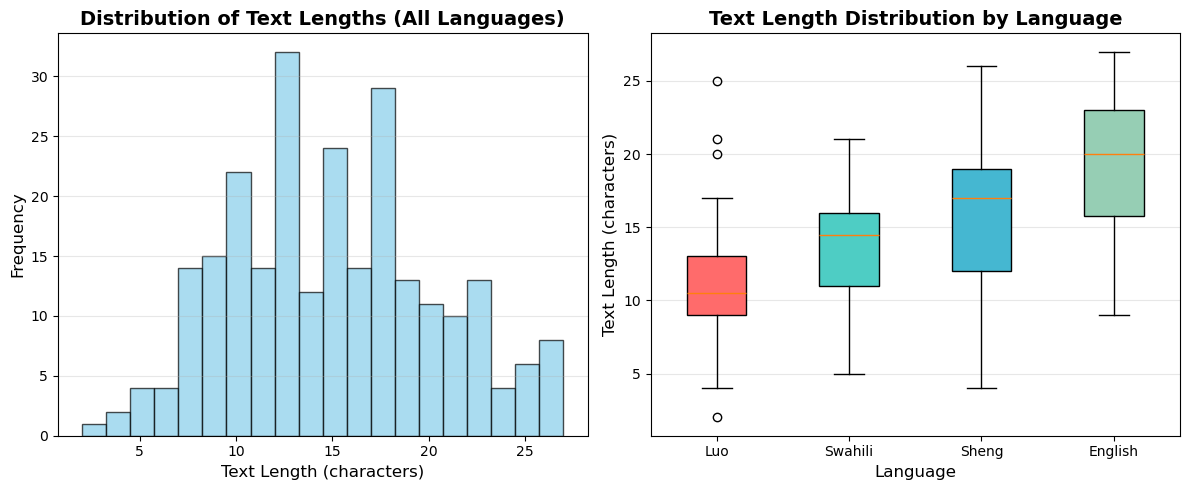


✅ Text length analysis complete!


In [ ]:
# CELL 10: Analyze text lengths

print("📏 TEXT LENGTH ANALYSIS")
print("=" * 50)

# Add text length column (number of characters)
df['text_length'] = df['text'].str.len()

print("\n📊 OVERALL TEXT LENGTH STATISTICS:")
print("-" * 40)
print(f"Minimum length: {df['text_length'].min()} characters")
print(f"Maximum length: {df['text_length'].max()} characters")
print(f"Average length: {df['text_length'].mean():.1f} characters")
print(f"Median length: {df['text_length'].median():.1f} characters")

# Statistics by language
print("\n📊 LENGTH STATISTICS BY LANGUAGE:")
print("-" * 40)
for lang in df['language'].unique():
    lang_data = df[df['language'] == lang]['text_length']
    print(f"\n{lang}:")
    print(f"   Min: {lang_data.min()} chars")
    print(f"   Max: {lang_data.max()} chars")
    print(f"   Avg: {lang_data.mean():.1f} chars")

# Create histogram
plt.figure(figsize=(12, 5))

# Plot histogram for all languages
plt.subplot(1, 2, 1)
plt.hist(df['text_length'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Text Lengths (All Languages)', fontsize=14, fontweight='bold')
plt.xlabel('Text Length (characters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Plot boxplot by language
plt.subplot(1, 2, 2)
lang_order = df.groupby('language')['text_length'].median().sort_values().index
box_data = [df[df['language'] == lang]['text_length'] for lang in lang_order]
box = plt.boxplot(box_data, labels=lang_order, patch_artist=True)

# Color the boxes
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Text Length Distribution by Language', fontsize=14, fontweight='bold')
plt.xlabel('Language', fontsize=12)
plt.ylabel('Text Length (characters)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Text length analysis complete!")

In [ ]:
# CELL 11: Save the dataset to CSV

print("💾 SAVING DATASET TO CSV")
print("=" * 50)

# Define file path
csv_filename = 'language_dataset_milestone1.csv'

# Save dataset (drop the text_length column for clean version)
df_clean = df.drop('text_length', axis=1)
df_clean.to_csv(csv_filename, index=False)

print(f"✅ Dataset saved to: {csv_filename}")

# Verify file was saved
if os.path.exists(csv_filename):
    file_size = os.path.getsize(csv_filename)
    print(f"📄 File size: {file_size} bytes ({file_size/1024:.2f} KB)")
    print(f"📋 Contains: {len(df_clean)} rows, {len(df_clean.columns)} columns")

# Show final summary
print("\n" + "=" * 50)
print("🎉 MILESTONE 1 COMPLETED SUCCESSFULLY!")
print("=" * 50)
print(f"Student: Maryivy Kibali (ID: 110062741)")
print(f"Date: 11th March 2026")
print(f"Total samples collected: {len(df_clean)}")
print("\nDistribution:")
for lang, count in df_clean['language'].value_counts().items():
    print(f"  {lang}: {count}")
print("\n✅ Ready for submission!")

💾 SAVING DATASET TO CSV
✅ Dataset saved to: language_dataset_milestone1.csv
📄 File size: 5654 bytes (5.52 KB)
📋 Contains: 252 rows, 2 columns

🎉 MILESTONE 1 COMPLETED SUCCESSFULLY!
Student: Maryivy Kibali (ID: 110062741)
Date: 11th March 2026
Total samples collected: 252

Distribution:
  Luo: 68
  English: 64
  Sheng: 60
  Swahili: 60

✅ Ready for submission!


In [ ]:
# CELL 12: Data Preprocessing

import re
import string

print("⚙️ DATA PREPROCESSING")
print("=" * 50)

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 3. Remove extra spaces
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    return text

# Apply preprocessing
df_clean = df.copy()
df_clean['clean_text'] = df_clean['text'].apply(preprocess_text)

# Show before and after
print("\n📋 BEFORE vs AFTER PREPROCESSING:")
print("-" * 50)
for i in range(5):
    print(f"Before: {df_clean['text'].iloc[i]}")
    print(f"After:  {df_clean['clean_text'].iloc[i]}")
    print()

print("✅ Preprocessing complete!")
print(f"Total samples processed: {len(df_clean)}")